# Score-functional subspace candidate reserve

## Откуда возникает этот эксперимент

Предыдущий эксперимент локализовал почти необходимый и почти достаточный mediator в объединении `5×5` окон clean target candidates на входе Detect head: полный local delta воспроизвёл 178/200 исходно успешных атак и 0/200 неуспешных. Но обычный activation-energy SVD не дал однонаправленного механизма. Target layout оказался даже менее низкоранговым, чем translated control; rank-1 repair достиг 100%, но random energy-matched repair — около 91.7%, а rank-1 transplant не воспроизвёл ни одного hiding.

Это означает, что ранжирование направлений по величине activation variance смешивает функционально важный для score сигнал с большим количеством feature energy, почти невидимого для person logits. Новый эксперимент ищет подпространство не по энергии активаций, а по совместному влиянию на score всего candidate reserve.

## Главная гипотеза

> Большая часть локального patch-induced activation delta функционально не видна score-ветви. Изменение person logits всех clean target candidates проходит через значительно более компактный score-functional row space.

## Постановка с приоритетом score

Для каждого изображения фиксируется тот же clean candidate reserve. В нескольких midpoint по пути от clean к patched Detect input считается Jacobian вектора фиксированных candidate person logits:

$$J_{path}=\int_0^1 \frac{\partial z_{candidates}(A_{clean}+\alpha\Delta A)}{\partial A}\,d\alpha.$$

При достаточном числе шагов выполняется vector completeness:

$$z_{patch}-z_{clean}=J_{path}\Delta A.$$

После SVD `J = UΣVᵀ` actual patch delta проектируется на правые singular directions. Моды ранжируются не по `σ`, а по реализованному patch effect `|σᵢ(vᵢᵀΔA)|²`. Поэтому высокая чувствительность без alignment с настоящим delta не считается механизмом.

Проверяются:

- `functional_rank1/2/4` — первые моды по actual score effect;
- `functional_all` — вся проекция delta в row space Jacobian;
- `null_residual` — остальная локальная activation energy;
- `sensitivity_rank1` — strongest-Jacobian mode без учёта alignment;
- `top-|delta|` и random controls с той же input energy, что functional rank-1;
- `full_target_windows` — прежний локальный oracle.

Интервенции применяются **только к classification/score branch `cv3`**. Box branch в repair остаётся patched, а в transplant — clean. Поэтому geometry не участвует в выборе направлений и остаётся лишь вторичным endpoint: изменения IoU возможны из-за выбора другого уже декодированного bbox после изменения score/NMS, но сами box features не заменяются.

Строгое подтверждение требует: хорошей vector completeness; малой input-energy доли row space; dose-dependent score repair/transplant; слабого null residual; преимущества effect-ranked modes над sensitivity-only и energy controls.

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

ROOT = Path.cwd()
if ROOT.name == 'CandidateRoutingAndAttackPath': ROOT = ROOT.parent
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from CandidateRoutingAndAttackPath.score_functional_subspace import (
    ScoreFunctionalSubspaceConfig, run_score_functional_subspace,
)
sns.set_theme(style='whitegrid', context='notebook')
OUTPUT_ROOT = ROOT / 'CandidateRoutingAndAttackPath' / 'followup_outputs'
RUN_EXPERIMENT = False
DEVICE = 'mps'
if RUN_EXPERIMENT:
    RUN_DIR = run_score_functional_subspace(ScoreFunctionalSubspaceConfig(
        device=DEVICE, require_device=(DEVICE == 'mps'), examples_per_group=25,
        path_steps=5, window_radius=2, ranks=(1, 2, 4),
        random_energy_controls=3, method_version=1,
    ))
else:
    candidates = []
    for path in OUTPUT_ROOT.glob('score_functional_*/summary.json'):
        value = json.loads(path.read_text())
        if value.get('status') == 'complete' and value.get('n_examples', 0) >= 100:
            candidates.append(path.parent)
    if not candidates: raise FileNotFoundError('Нет полного score_functional run')
    RUN_DIR = max(candidates, key=lambda path: path.stat().st_mtime)
summary = json.loads((RUN_DIR / 'summary.json').read_text())
spectrum = pd.read_csv(RUN_DIR / 'functional_spectrum_rows.csv')
spectrum_summary = pd.read_csv(RUN_DIR / 'functional_spectrum_summary.csv')
rows = pd.read_csv(RUN_DIR / 'intervention_rows.csv')
interventions = pd.read_csv(RUN_DIR / 'intervention_summary.csv')
display(Markdown(f"**Run:** `{RUN_DIR.name}` · **N:** {summary['n_examples']} · **time:** {summary['elapsed_seconds']:.1f} s"))

**Run:** `score_functional_c6cde98c330611ca` · **N:** 400 · **time:** 10467.1 s

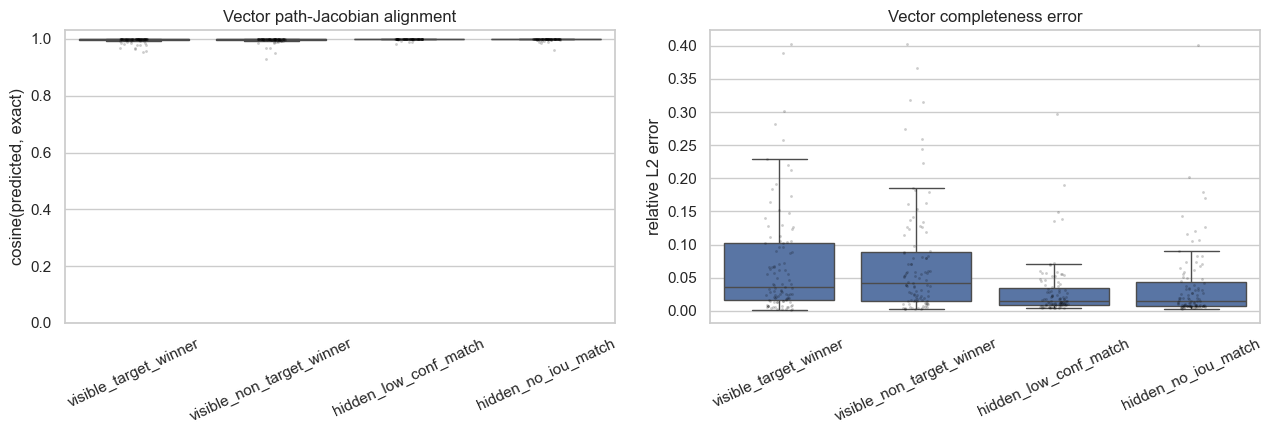

In [2]:
order = ['visible_target_winner', 'visible_non_target_winner',
         'hidden_low_conf_match', 'hidden_no_iou_match']
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=spectrum, x='analysis_group', y='jacobian_cosine', order=order,
            showfliers=False, ax=axes[0])
sns.stripplot(data=spectrum, x='analysis_group', y='jacobian_cosine', order=order,
              color='black', alpha=.2, size=2, ax=axes[0])
axes[0].set(title='Vector path-Jacobian alignment', xlabel='', ylabel='cosine(predicted, exact)', ylim=(0, 1.03))
axes[0].tick_params(axis='x', rotation=25)
sns.boxplot(data=spectrum, x='analysis_group', y='jacobian_relative_error', order=order,
            showfliers=False, ax=axes[1])
sns.stripplot(data=spectrum, x='analysis_group', y='jacobian_relative_error', order=order,
              color='black', alpha=.2, size=2, ax=axes[1])
axes[1].set(title='Vector completeness error', xlabel='', ylabel='relative L2 error')
axes[1].tick_params(axis='x', rotation=25)
plt.tight_layout(); plt.show()

**Что видно.** Пяти midpoint достаточно для очень точной vector decomposition: средний cosine между предсказанным и exact вектором candidate-logit changes равен 0.998, средняя relative L2 error — 0.053. Медианная ошибка ещё ниже: примерно 0.015–0.043 в зависимости от группы. Направление изменения восстанавливается почти идеально, поэтому `σᵢ(vᵢᵀΔA)` можно содержательно интерпретировать как реализованный score effect. Visible-группы имеют несколько большую среднюю ошибку из-за отдельных outliers, но cosine остаётся около 0.996.

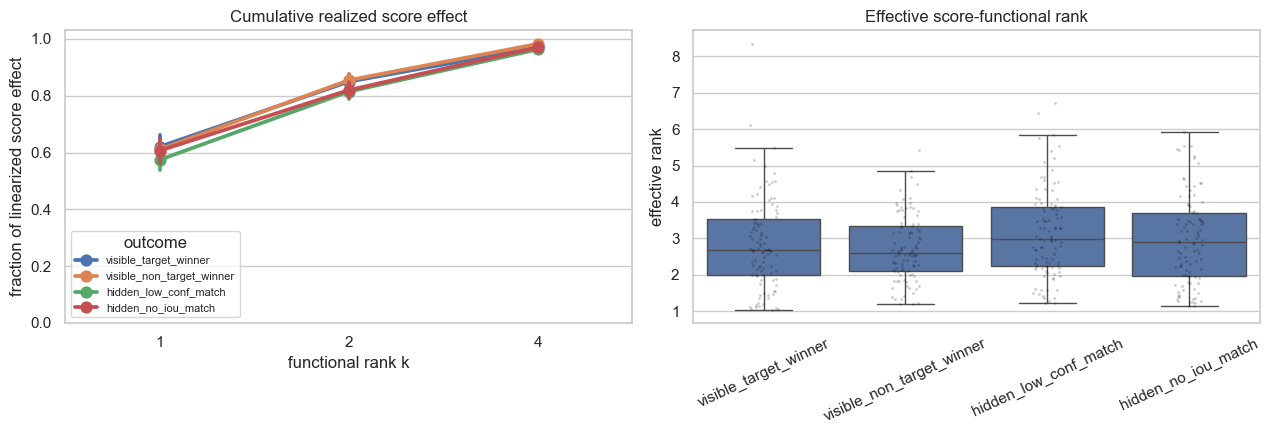

In [3]:
effect_long = spectrum.melt(
    id_vars=['example_id', 'analysis_group'],
    value_vars=['rank1_effect_fraction', 'rank2_effect_fraction', 'rank4_effect_fraction'],
    var_name='rank', value_name='effect_fraction',
)
effect_long['rank_k'] = effect_long['rank'].str.extract(r'rank(\d+)').astype(int)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.pointplot(data=effect_long, x='rank_k', y='effect_fraction', hue='analysis_group',
              hue_order=order, errorbar=('ci', 95), marker='o', ax=axes[0])
axes[0].set(title='Cumulative realized score effect', xlabel='functional rank k',
            ylabel='fraction of linearized score effect', ylim=(0, 1.03))
axes[0].legend(title='outcome', fontsize=8)
sns.boxplot(data=spectrum, x='analysis_group', y='functional_effective_rank',
            order=order, showfliers=False, ax=axes[1])
sns.stripplot(data=spectrum, x='analysis_group', y='functional_effective_rank',
              order=order, color='black', alpha=.2, size=2, ax=axes[1])
axes[1].set(title='Effective score-functional rank', xlabel='', ylabel='effective rank')
axes[1].tick_params(axis='x', rotation=25)
plt.tight_layout(); plt.show()

**Что видно.** Score effect действительно компактен для всех групп: rank-1 объясняет 57–62%, rank-2 — 81–85%, rank-4 — 96–98%; effective rank около 2.7–3.1. Но hidden-группы не более низкоранговые: у них rank-2/rank-4 fractions немного ниже, а effective rank немного выше. Следовательно, малый functional rank — общая особенность score head, а не сам критерий успеха. Успешное скрытие требует скорее большего alignment patch delta с этим subspace и согласованного действия нескольких мод, а не схлопывания в одну direction.

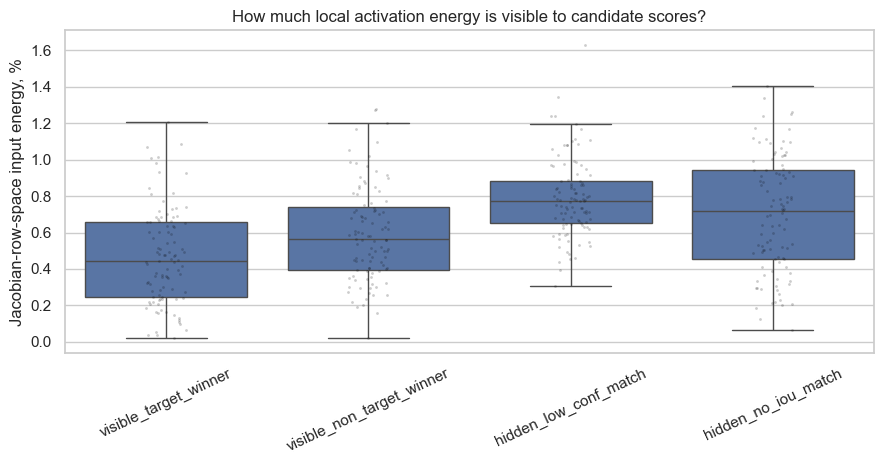

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.8))
energy = spectrum.copy()
energy['rowspace_percent'] = 100 * energy.rowspace_input_energy_fraction
sns.boxplot(data=energy, x='analysis_group', y='rowspace_percent', order=order,
            showfliers=False, ax=ax)
sns.stripplot(data=energy, x='analysis_group', y='rowspace_percent', order=order,
              color='black', alpha=.2, size=2, ax=ax)
ax.set(title='How much local activation energy is visible to candidate scores?',
       xlabel='', ylabel='Jacobian-row-space input energy, %')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout(); plt.show()

**Что видно.** В среднем всего 0.64% squared activation energy лежит в score-Jacobian row space. Для hidden эта доля выше, чем для visible: 0.74% против 0.53%; single-metric ROC AUC равен 0.718, `p≈4.5e−14`. Это поддерживает уточнённую версию старой гипотезы «расползся куда нужно»: важна не общая энергия delta, а малая доля, попавшая в score-sensitive subspace. При этом более 99% локальной feature energy находится вне линейно видимого score space.

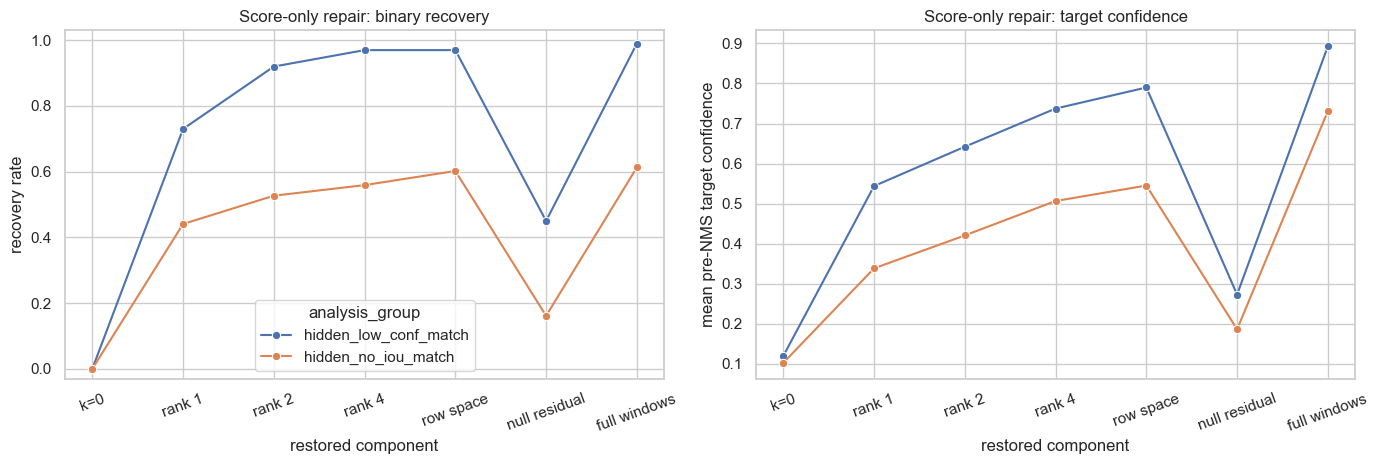

In [5]:
dose = ['none', 'functional_rank1', 'functional_rank2', 'functional_rank4',
        'functional_all', 'null_residual', 'full_target_windows']
labels = {'none':'k=0', 'functional_rank1':'rank 1', 'functional_rank2':'rank 2',
          'functional_rank4':'rank 4', 'functional_all':'row space',
          'null_residual':'null residual', 'full_target_windows':'full windows'}
repair = interventions[(interventions.direction=='repair_patched') &
                       (interventions.analysis_group!='all') & interventions.condition.isin(dose)].copy()
repair['condition'] = pd.Categorical(repair.condition, dose, ordered=True)
repair['label'] = repair.condition.astype(str).map(labels)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
sns.lineplot(data=repair.sort_values('condition'), x='label', y='recovery_rate',
             hue='analysis_group', hue_order=order[2:], marker='o', ax=axes[0])
axes[0].set(title='Score-only repair: binary recovery', xlabel='restored component',
            ylabel='recovery rate', ylim=(-.03,1.03))
axes[0].tick_params(axis='x', rotation=20)
sns.lineplot(data=repair.sort_values('condition'), x='label', y='mean_pre_target_conf',
             hue='analysis_group', hue_order=order[2:], marker='o', ax=axes[1], legend=False)
axes[1].set(title='Score-only repair: target confidence', xlabel='restored component',
            ylabel='mean pre-NMS target confidence')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

**Что видно.** Для low-confidence pre-NMS confidence растёт с 0.120 до 0.544 уже на rank-1, до 0.642 на rank-2 и до 0.790 на полном row space; recovery составляет 73%, 92% и 97%. Full class-window oracle даёт 0.893 и 99%. Для no-IoU соответствующие confidence равны 0.103→0.339→0.421→0.545, recovery 44%, 52.7%, 60.2%; полный oracle — 0.731 и 61.3%. То есть row space с 0.7–0.8% activation energy практически исчерпывает score-only rescue. Оставшийся потолок no-IoU объясняется patched geometry: score восстанавливается, но не у каждого bbox появляется IoU≥0.5. Null residual содержит более 99% энергии, однако даёт лишь 45%/16% recovery и намного меньший confidence.

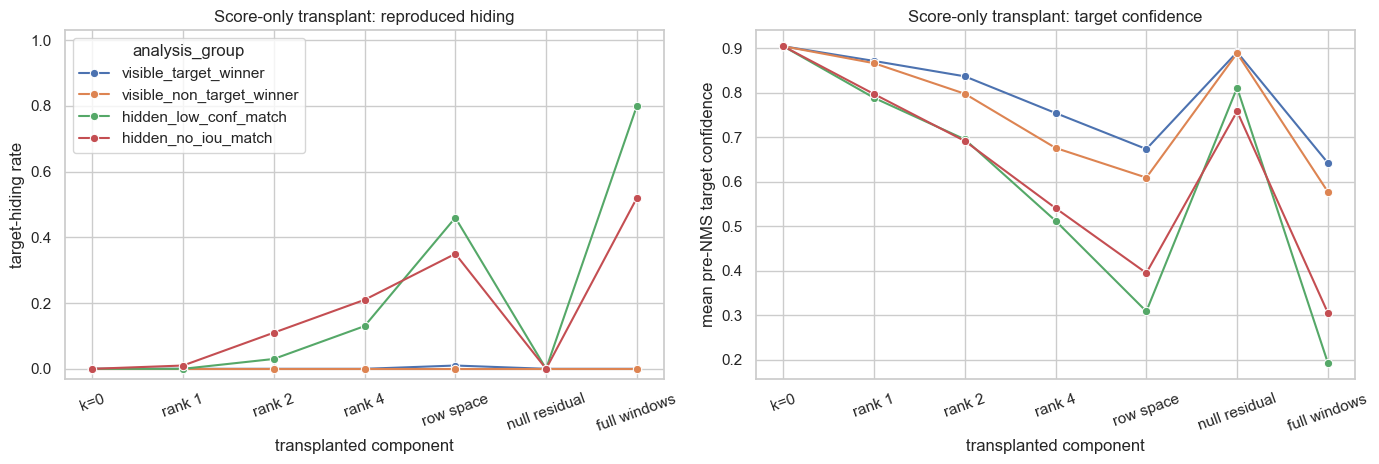

In [6]:
transplant = interventions[(interventions.direction=='transplant_clean') &
                           (interventions.analysis_group!='all') & interventions.condition.isin(dose)].copy()
transplant['condition'] = pd.Categorical(transplant.condition, dose, ordered=True)
transplant['label'] = transplant.condition.astype(str).map(labels)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
sns.lineplot(data=transplant.sort_values('condition'), x='label', y='reproduced_hiding_rate',
             hue='analysis_group', hue_order=order, marker='o', ax=axes[0])
axes[0].set(title='Score-only transplant: reproduced hiding', xlabel='transplanted component',
            ylabel='target-hiding rate', ylim=(-.03,1.03))
axes[0].tick_params(axis='x', rotation=20)
sns.lineplot(data=transplant.sort_values('condition'), x='label', y='mean_pre_target_conf',
             hue='analysis_group', hue_order=order, marker='o', ax=axes[1], legend=False)
axes[1].set(title='Score-only transplant: target confidence', xlabel='transplanted component',
            ylabel='mean pre-NMS target confidence')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

**Что видно.** На чистой геометрии full score-functional row space воспроизводит hiding в 46% low-confidence и 35% no-IoU source-примеров, но только в 1%/0% visible-групп. Full class-window delta даёт 80% и 52%, также 0% в visible. Null residual не скрывает ни одного target, несмотря на более чем 99% input energy. Значит, компактный row space действительно sufficient для существенной части score collapse и специфичен для успешных endpoint deltas. Однако разрыв `row space → full windows` показывает нелинейный вклад residual и взаимодействие row/null компонентов: first-order функциональная проекция не содержит весь реализуемый score effect.

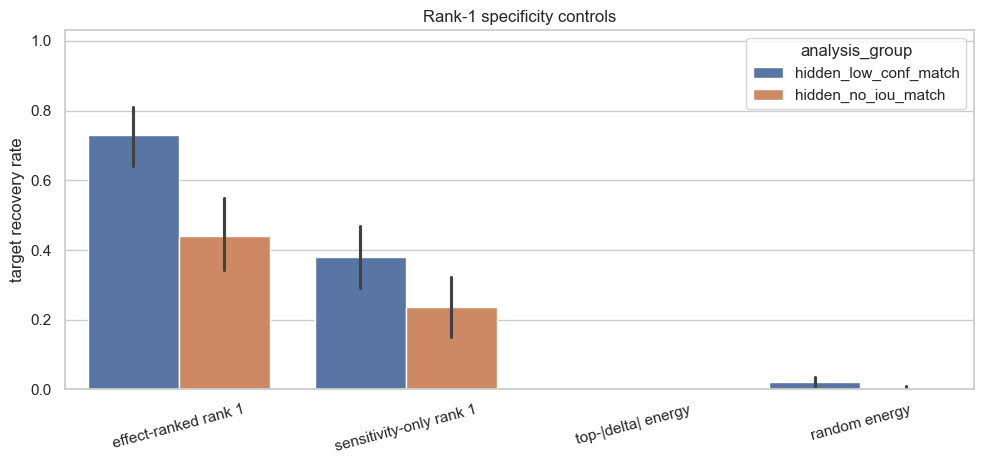

In [7]:
controls = ['functional_rank1','sensitivity_rank1','topabs_energy_rank1',
            'random_energy_rank1_0','random_energy_rank1_1','random_energy_rank1_2']
control_rows = rows[(rows.direction=='repair_patched') & rows.condition.isin(controls) &
                    rows.baseline_hidden.eq(1)].copy()
control_rows['strategy'] = np.select(
    [control_rows.condition.eq('functional_rank1'), control_rows.condition.eq('sensitivity_rank1'),
     control_rows.condition.eq('topabs_energy_rank1'), control_rows.condition.str.startswith('random_')],
    ['effect-ranked rank 1','sensitivity-only rank 1','top-|delta| energy','random energy'], default='other')
fig, ax = plt.subplots(figsize=(10, 4.8))
sns.barplot(data=control_rows, x='strategy', y='target_detected', hue='analysis_group',
            hue_order=order[2:], errorbar=('ci',95), ax=ax)
ax.set(title='Rank-1 specificity controls', xlabel='', ylabel='target recovery rate', ylim=(0,1.03))
ax.tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()

**Что видно.** Effect-ranked rank-1 существенно лучше sensitivity-only: recovery 73% против 38% для low-confidence и 44% против 23.7% для no-IoU. Следовательно, одной чувствительности модели недостаточно — нужно учитывать alignment с настоящим patch delta. Top-|delta| control с той же input energy даёт 0% recovery, random controls — около 0–1%. Это сильное преимущество над controls, которого не было у activation-energy SVD: функциональный Jacobian действительно выделяет специфический score mediator, а не просто удобный объём восстановления.

In [8]:
display(spectrum.groupby('analysis_group')[[
    'rank1_effect_fraction','rank2_effect_fraction','rank4_effect_fraction',
    'functional_effective_rank','rowspace_input_energy_fraction',
    'jacobian_relative_error','jacobian_cosine',
]].mean().round(4))
display(interventions[interventions.analysis_group.eq('all')][[
    'direction','condition','mean_component_energy_fraction','recovery_rate',
    'reproduced_hiding_rate','mean_pre_target_conf','mean_tracked_score',
    'mean_post_target_conf','mean_post_target_iou',
]].round(4))

,rank1_effect_fraction,rank2_effect_fraction,rank4_effect_fraction,functional_effective_rank,rowspace_input_energy_fraction,jacobian_relative_error,jacobian_cosine
analysis_group,,,,,,,
hidden_low_conf_match,0.5742,0.8142,0.9631,3.1382,0.0079,0.0298,0.9992
hidden_no_iou_match,0.6064,0.8194,0.9699,2.9464,0.0070,0.0372,0.9987
visible_non_target_winner,0.6110,0.8546,0.9823,2.7241,0.0059,0.0729,0.9964
visible_target_winner,0.6203,0.8492,0.9698,2.8388,0.0047,0.0704,0.9959


,direction,condition,mean_component_energy_fraction,recovery_rate,reproduced_hiding_rate,mean_pre_target_conf,mean_tracked_score,mean_post_target_conf,mean_post_target_iou
96,repair_patched,none,0.0000,0.0000,0.0000,0.3545,0.2542,0.3359,0.7223
97,repair_patched,functional_rank1,0.0027,0.5907,0.0097,0.5577,0.4434,0.5367,0.7894
98,repair_patched,functional_rank2,0.0041,0.7306,0.0048,0.6426,0.5679,0.6174,0.7977
99,repair_patched,functional_rank4,0.0055,0.7720,0.0048,0.7417,0.7137,0.7067,0.8012
100,repair_patched,functional_all,0.0064,0.7927,0.0048,0.7786,0.7776,0.7440,0.7993
101,repair_patched,sensitivity_rank1,0.0015,0.3109,0.0048,0.4617,0.3417,0.4367,0.7608
102,repair_patched,topabs_energy_rank1,0.0027,0.0000,0.0048,0.3547,0.2543,0.3360,0.7238
103,repair_patched,random_energy_rank1_0,0.0027,0.0052,0.0048,0.3557,0.2556,0.3370,0.7221
104,repair_patched,random_energy_rank1_1,0.0027,0.0207,0.0000,0.3561,0.2555,0.3392,0.7251
105,repair_patched,random_energy_rank1_2,0.0027,0.0104,0.0048,0.3564,0.2553,0.3365,0.7212


## Итог

Основной результат: path-integrated Jacobian отделяет очень малый (`≈0.64%` activation energy), но причинно специфичный score-functional subspace. Его полный repair почти совпадает с full class-window oracle: 97% против 99% low-confidence recovery и 60.2% против 61.3% no-IoU recovery. Равные по энергии top-|delta| и random interventions почти не работают. Full row-space transplant воспроизводит 46%/35% hidden-source атак и практически 0% visible-source, тогда как null residual с более чем 99% энергии не воспроизводит ни одной.

При этом научный тезис — не «успешная атака имеет меньший rank»: functional rank примерно три во всех группах и даже немного выше у hidden. Различие успеха связано с тем, сколько настоящего patch delta попало в score-sensitive row space, и с многомодовым согласованным подавлением candidate logits. Geometry остаётся отдельным ограничителем no-IoU recovery, но не используется для построения subspace.

Следующий защитный шаг: использовать согласованное изменение candidate-score subspace как сигнал аномалии или точку минимальной интервенции. Для этого oracle per-image Jacobian нужно заменить приближением без clean reference — например, локальной стабильностью candidate ensemble к малым feature probes или заранее оценённым class-head sensitive basis — и обязательно проверить против adaptive patch.